<a href="https://colab.research.google.com/github/dmousa75/Masters_DataAnalytics-FinalReport/blob/main/Copy_of_Final_Report_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Title**

A Big Data Analytics Framework for Predicting Malaysian Parliamentary Election Outcomes Using Apache Hive and Machine Learning

# **Project Objectives**

1- To preprocess and manage the Malaysian election dataset using Apache Hive by importing, organizing, cleaning, and transforming large-scale election data into a structured format suitable for analysis.

2- To perform exploratory data analysis (EDA) and data preprocessing using Python in Google Colab in order to understand the characteristics, distributions, relationships, and quality of the election dataset.

3- To develop and compare multiple machine learning models, including Logistic Regression, Decision Tree, Random Forest, and XGBoost, for predicting parliamentary election outcomes.

4- To investigate the effectiveness of class imbalance handling techniques, including class weighting, SMOTE, and threshold moving, in improving prediction performance.

5- To evaluate and compare the predictive performance of the developed models using Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrices, and ROC curves to identify the most suitable model for election outcome prediction.

**Expected Outcomes**

At the end of this project, the study is expected to:

Produce a clean and structured election dataset using Apache Hive.
Demonstrate an end-to-end big data analytics workflow integrating Hive and Python.
Build predictive models capable of forecasting parliamentary election outcomes.
Compare the strengths and weaknesses of different machine learning algorithms.
Identify the most effective approach for handling imbalanced election data.
Provide insights into the factors influencing election outcomes in Malaysia.

# **Dataset Description**

###**1- Overview**

This study uses a dataset containing information from Malaysia's 14th General Election (GE14) held in 2018 and the 15th General Election (GE15) held in 2022. The dataset was compiled from publicly available election results and demographic information at the parliamentary constituency level.

The objective of the dataset is to support the analysis and prediction of parliamentary election outcomes by combining historical election performance with constituency demographic characteristics.

###**2- Dataset Source**

The dataset was compiled from multiple publicly available sources, including:

+ Official election results published by the Election Commission of Malaysia (Suruhanjaya Pilihan Raya Malaysia, SPR)
+ Public demographic and voter statistics
+ Constituency-level electoral information for GE14 and GE15

The data from these sources were integrated into a single structured dataset for analysis.

###**3- Dataset Structure**

The final processed dataset contains:

###**Dataset Structure**

| Attribute | Description |
|-----------|-------------|
| Number of observations | 191 parliamentary constituencies |
| Number of variables | 107 features |
| Unit of analysis | Parliamentary constituency |
| File format | CSV |
| Processing tool | Apache Hive |
| Analysis tool | Google Colab (Python) |

Each row represents one parliamentary constituency, while each column contains demographic, electoral, or voting information related to that constituency.

###**4- Dataset Variables**

The dataset includes several categories of variables:

**4.1. Constituency Information**

These variables identify each parliamentary constituency.

Examples:

+ State
+ Constituency
+ Parliament Code
+ Parliament Name
+ Number of DUN
+ Number of PDM

**4.2. Demographic Variables**

These variables describe the composition of registered voters.

Examples include:

+ Total registered voters
+ Malay voters
+ Chinese voters
+ Indian voters
+ Bumiputera Sabah voters
+ Bumiputera Sarawak voters
+ Orang Asli voters

**4.3. Election Participation**

Variables describing voter participation include:

+ Voter turnout (GE15)
+ Total valid votes

**4.4. Election Results**

Historical election outcomes are included for both GE14 and GE15.

Examples:

+ Winning party
+ Winning candidate
+ Majority votes
+ Vote counts for major political parties

**4.5. Political Party Variables**

The dataset records votes received by major political coalitions, including:

+ Barisan Nasional (BN)
+ Pakatan Harapan (PH)
+ Perikatan Nasional (PN)
+ Parti Islam Se-Malaysia (PAS) (primarily relevant for GE14 in your dataset)

**4.6. Target Variable**

The prediction target is:

**Party_Win_GE15**

This variable identifies the political coalition that won each parliamentary constituency during GE15.

It serves as the dependent variable for the machine learning models.

###**5- Data Types**

The dataset contains a mixture of categorical and numerical variables.

| Data Type	| Examples |
|-----------|----------|
| Categorical	| State, Constituency, Winning Party, Candidate Name|
| Numerical	| Vote Counts, Majority, Voter Turnout, Number of Voters|

###**6- Data Preprocessing**

Before performing machine learning analysis, the dataset underwent several preprocessing steps using Apache Hive and Python.

These included:

+ Importing raw CSV data into Apache Hive
+ Structuring the dataset using Hive tables
+ Data validation
+ Handling missing values
+ Data type conversion
+ Exporting the cleaned dataset from Hive
+ Additional preprocessing and feature preparation in Google Colab

These steps ensured that the dataset was consistent and suitable for predictive modeling.

# **Section 1 : Apache Hive Processing**

Election Prediction using Apache Hive and Machine Learning

This project uses Apache Hive for large-scale data processing and Google Colab (Python) for machine learning analysis.

## A) Hive Data Processing

### Step 1: Creating Hive Database

In [ ]:
CREATE DATABASE election_db;
USE election_db;

### Step 2:Creating Hive Table

In [ ]:
CREATE TABLE election_raw2 (
    state STRING,
    constituency STRING,
    parliament_code STRING,
    ...
)
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ',';

### Step 3: Loading CSV

In [ ]:
LOAD DATA INPATH '/user/maria_dev/GE14_GE15_Final.csv'
INTO TABLE election_raw2;

### Step 4: Checking Data

In [ ]:
SELECT * FROM election_raw2 LIMIT 10;

### Step 5: Cleaning Data

In [ ]:
SELECT
state,
constituency,
COALESCE(num_of_dun,0) AS num_of_dun
FROM election_raw2;

### Step 6: Export Cleaned Data

In [ ]:
INSERT OVERWRITE DIRECTORY
'/user/maria_dev/election_export'
ROW FORMAT DELIMITED
FIELDS TERMINATED BY ','
SELECT * FROM election_raw2;

# **Section 2: Import Processed Data into Google Colab**

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
!ls -lh /content

total 8.0K
drwx------ 5 root root 4.0K Jun 30 04:55 drive
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [ ]:
import os

for file in os.listdir('/content/drive/MyDrive/Election_Analytics'):
    print(file)

election_raw3.csv
GE14_GE15_Final.csv
election_raw2_final.csv
election_raw2_final (1).csv
election_raw2_final_a.csv
.ipynb_checkpoints
election_raw2_final (2).csv
election_raw2_clean.csv
real_election_raw2_clean.csv
election_master_v2.csv


## Step 1 : Install Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

## Step 2: Upload File

In [ ]:
#Upload 'election_raw3.csv'
from google.colab import files
uploaded = files.upload()

Saving election_raw3.csv to election_raw3.csv


In [ ]:
!ls -lh

total 124K
drwx------ 5 root root 4.0K Jun 30 04:55 drive
-rw-r--r-- 1 root root 115K Jun 30 05:07 election_raw3.csv
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


## Step 3 : Check Dataset

In [ ]:
# Read first 100 bytes of a file in binary codes
with open('election_raw3.csv', 'rb') as f:
    print(f.read(100))

b'PERLIS,PARLIMEN,1,001 PADANG BESAR,5,27,0.765,GE15,PN,RUSHDAN BIN RUSMI ,11753, UMNO,ZAHIDA BINTI ZA'


In [ ]:
# Change working directory
import os
os.chdir('/content/drive/MyDrive/Election_Analytics')


In [ ]:
# Upload the file 'election_raw3.csv' exported from Hive
df = pd.read_csv(
    'election_raw3.csv',
    header=None
)

print(df.shape)
df.head()

(191, 107)


,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
0,PERLIS,PARLIMEN,1,001 PADANG BESAR,5,27,0.765,GE15,PN,RUSHDAN BIN RUSMI,...,10869,21292,7471,9734,2739,1348,134,134,134,123
1,PERLIS,PARLIMEN,2,002 KANGAR,5,31,0.761,GE15,PN,CIKGU ZAKRI,...,14057,17255,5839,8242,2147,1027,122,122,121,116
2,PERLIS,PARLIMEN,3,003 ARAU,5,30,0.782,GE15,PN,SHAHIDAN BIN KASIM,...,11378,20307,7235,9330,2461,1281,133,132,132,128
3,KEDAH,PARLIMEN,4,004 LANGKAWI,2,27,0.721,GE15,PN,MOHD SUHAIMI ABDULLAH,...,8294,14129,4821,5923,1718,1667,103,103,101,101
4,KEDAH,PARLIMEN,5,005 JERLUN,2,35,0.783,GE15,PN,DR. ABD GHANI AHMAD,...,13570,20681,8025,9375,2174,1107,168,168,166,150


In [ ]:
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
0,PERLIS,PARLIMEN,1,001 PADANG BESAR,5,27,0.765,GE15,PN,RUSHDAN BIN RUSMI,...,10869,21292,7471,9734,2739,1348,134,134,134,123
1,PERLIS,PARLIMEN,2,002 KANGAR,5,31,0.761,GE15,PN,CIKGU ZAKRI,...,14057,17255,5839,8242,2147,1027,122,122,121,116
2,PERLIS,PARLIMEN,3,003 ARAU,5,30,0.782,GE15,PN,SHAHIDAN BIN KASIM,...,11378,20307,7235,9330,2461,1281,133,132,132,128
3,KEDAH,PARLIMEN,4,004 LANGKAWI,2,27,0.721,GE15,PN,MOHD SUHAIMI ABDULLAH,...,8294,14129,4821,5923,1718,1667,103,103,101,101
4,KEDAH,PARLIMEN,5,005 JERLUN,2,35,0.783,GE15,PN,DR. ABD GHANI AHMAD,...,13570,20681,8025,9375,2174,1107,168,168,166,150


We see there is no headers for this dataset. To get all the headers's name we need to export with headers from hive. Check again from Hive or choose only columns that matters for our analysis.

### a) Export from Hive using TAB Delimeter

In [ ]:
for i in range(107):
    print(i, ":", df.iloc[0, i])

0 : PERLIS
1 : PARLIMEN
2 : 1
3 : 001 PADANG BESAR
4 : 5
5 : 27
6 : 0.765
7 : GE15
8 : PN
9 : RUSHDAN BIN RUSMI 
10 : 11753
11 :  UMNO
12 : ZAHIDA BINTI ZARIKH KHAN 
13 : 7085
14 : AMANAH
15 : KAPT (B) HJ MOHAMAD YAHAYA 
16 : 24267
17 :  PAS
18 : RUSHDAN BIN RUSMI 
19 : 12514
20 : 0
21 : 0
22 : 1
23 : 35063
24 : BN-UMNO
25 : GE14
26 : ZAHIDI BIN ZAINUL ABIDIN
27 : 1438
28 : 0.812
29 : 27894
30 : 15032
31 : 7874
32 : 13594
33 : UMNO
34 : PPBM
35 : 1
36 : 0
37 : 0
38 : 46096
39 : 39914
40 : 3895
41 : 413
42 : 1403
43 : 160
44 : 304
45 : 7
46 : 23084
47 : 23012
48 : 19821
49 : 26275
50 : 17832
51 : 60192
52 : 9
53 : 2191
54 : 57992
55 : 51890
56 : 0.862
57 : 4862
58 : 0.081
59 : 533
60 : 0.009
61 : 6
62 : 192
63 : 327
64 : 2382
65 : 2907
66 : 0.583
67 : 26761
68 : 17218
69 : 10015
70 : 3234
71 : 29090
72 : 16967
73 : 10901
74 : 32324
75 : 27868
76 : 61462
77 : 0
78 : 1843
79 : 59619
80 : 53293
81 : 4643
82 : 517
83 : 7
84 : 185
85 : 308
86 : 2509
87 : 3009
88 : 30749
89 : 30713
90 : 30603

### b) Read again the dataset exported from Hive.

The file was saved as 'election_raw2_final.csv'.

## Change working Directory

In [ ]:
# Change working directory ( make sure filed saved in working directory)
import os
os.chdir('/content/drive/MyDrive/Election_Analytics')

In [ ]:
# Open file 'election_raw2_final.csv' exported from Hive
import pandas as pd

df_1 = pd.read_csv("election_raw2_final.csv")

print(df.shape)
df.head()

(191, 107)


,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
0,PERLIS,PARLIMEN,1,001 PADANG BESAR,5,27,0.765,GE15,PN,RUSHDAN BIN RUSMI,...,10869,21292,7471,9734,2739,1348,134,134,134,123
1,PERLIS,PARLIMEN,2,002 KANGAR,5,31,0.761,GE15,PN,CIKGU ZAKRI,...,14057,17255,5839,8242,2147,1027,122,122,121,116
2,PERLIS,PARLIMEN,3,003 ARAU,5,30,0.782,GE15,PN,SHAHIDAN BIN KASIM,...,11378,20307,7235,9330,2461,1281,133,132,132,128
3,KEDAH,PARLIMEN,4,004 LANGKAWI,2,27,0.721,GE15,PN,MOHD SUHAIMI ABDULLAH,...,8294,14129,4821,5923,1718,1667,103,103,101,101
4,KEDAH,PARLIMEN,5,005 JERLUN,2,35,0.783,GE15,PN,DR. ABD GHANI AHMAD,...,13570,20681,8025,9375,2174,1107,168,168,166,150


In [ ]:
# Check the headers
print(df_1.columns.tolist())

['election_raw2.state', 'election_raw2.constituency', 'election_raw2.parliament_code', 'election_raw2.parliament', 'election_raw2.num_of_dun', 'election_raw2.num_of_pdm', 'election_raw2.turn_out_spr_ge15', 'election_raw2.election_year_15', 'election_raw2.party_win_ge15', 'election_raw2.candidate_win_ge15', 'election_raw2.bn_votes_ge15', 'election_raw2.bn_components_ge15', 'election_raw2.bn_candidates_ge15', 'election_raw2.ph_votes_ge15', 'election_raw2.ph_components_ge15', 'election_raw2.ph_candidates_ge15', 'election_raw2.pn_votes_ge15', 'election_raw2.pn_components_ge15', 'election_raw2.pn_candidates_ge15', 'election_raw2.majority_ge15', 'election_raw2.bn_status_ge15', 'election_raw2.ph_status_ge15', 'election_raw2.pn_status_ge15', 'election_raw2.base_stock_ge15', 'election_raw2.party_win_ge14', 'election_raw2.election_year_14', 'election_raw2.candidate_win_ge14', 'election_raw2.majority_ge14', 'election_raw2.turn_out_spr_ge14', 'election_raw2.base_stock_ge14', 'election_raw2.bn_vote

In [ ]:
# Clean the columns
df_1.columns = df_1.columns.str.replace("election_raw2.", "", regex=False)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,97,98,99,100,101,102,103,104,105,106
0,PERLIS,PARLIMEN,1,001 PADANG BESAR,5,27,0.765,GE15,PN,RUSHDAN BIN RUSMI,...,10869,21292,7471,9734,2739,1348,134,134,134,123
1,PERLIS,PARLIMEN,2,002 KANGAR,5,31,0.761,GE15,PN,CIKGU ZAKRI,...,14057,17255,5839,8242,2147,1027,122,122,121,116
2,PERLIS,PARLIMEN,3,003 ARAU,5,30,0.782,GE15,PN,SHAHIDAN BIN KASIM,...,11378,20307,7235,9330,2461,1281,133,132,132,128
3,KEDAH,PARLIMEN,4,004 LANGKAWI,2,27,0.721,GE15,PN,MOHD SUHAIMI ABDULLAH,...,8294,14129,4821,5923,1718,1667,103,103,101,101
4,KEDAH,PARLIMEN,5,005 JERLUN,2,35,0.783,GE15,PN,DR. ABD GHANI AHMAD,...,13570,20681,8025,9375,2174,1107,168,168,166,150


In [ ]:
# Check the headers
print(df_1.columns.tolist()[:10])

['state', 'constituency', 'parliament_code', 'parliament', 'num_of_dun', 'num_of_pdm', 'turn_out_spr_ge15', 'election_year_15', 'party_win_ge15', 'candidate_win_ge15']


In [ ]:
# Save the cleaned dataset
df_1.to_csv(
    "election_raw2_clean.csv",
    index=False
)

In [ ]:
# Check the cleaned dataset
# check the header (head)
print(df_1.shape)

print(df_1.head(3))

(192, 107)
    state constituency  parliament_code        parliament  num_of_dun  \
0  PERLIS     PARLIMEN              1.0  001 PADANG BESAR         5.0   
1  PERLIS     PARLIMEN              2.0        002 KANGAR         5.0   
2  PERLIS     PARLIMEN              3.0          003 ARAU         5.0   

   num_of_pdm  turn_out_spr_ge15 election_year_15 party_win_ge15  \
0        27.0              0.765             GE15             PN   
1        31.0              0.761             GE15             PN   
2        30.0              0.782             GE15             PN   

    candidate_win_ge15  ...       u3 members_all members_man  members_woman  \
0   RUSHDAN BIN RUSMI   ...  10869.0     21292.0      7471.0         9734.0   
1         CIKGU ZAKRI   ...  14057.0     17255.0      5839.0         8242.0   
2  SHAHIDAN BIN KASIM   ...  11378.0     20307.0      7235.0         9330.0   

  members_youth members_pu3  num_branch num_womanbranch num_youthbranch  \
0        2739.0      1348.0    

In [ ]:
# Check the tail , we see the NaN row at last
print(df_1.tail(3))

                                 state constituency  parliament_code  \
189                              SABAH     PARLIMEN            190.0   
190                              SABAH     PARLIMEN            191.0   
191  191 rows selected (2.066 seconds)          NaN              NaN   

        parliament  num_of_dun  num_of_pdm  turn_out_spr_ge15  \
189      190 TAWAU         NaN        23.0              0.590   
190  191 KALABAKAN         NaN        21.0              0.605   
191            NaN         NaN         NaN                NaN   

    election_year_15 party_win_ge15                candidate_win_ge15  ...  \
189             GE15            GRS                         LO SU FUI  ...   
190             GE15             BN  ANDI MUHAMMAD SURYADY BIN BANDY   ...   
191              NaN            NaN                               NaN  ...   

          u3 members_all members_man  members_woman members_youth members_pu3  \
189  16533.0     27123.0     11384.0        10707.0     

In [ ]:
# confirm the blank row
df_1[df_1.isnull().all(axis=1)]

,state,constituency,parliament_code,parliament,num_of_dun,num_of_pdm,turn_out_spr_ge15,election_year_15,party_win_ge15,candidate_win_ge15,...,u3,members_all,members_man,members_woman,members_youth,members_pu3,num_branch,num_womanbranch,num_youthbranch,num_pu3_branch


In [ ]:
# Remove the last row at column 'state'
df_1 = df_1[df_1["state"] != "191 rows selected (2.066 seconds)"]

In [ ]:
# Reset the Index
df_1.reset_index(drop=True, inplace=True)

print(df_1.tail())

     state constituency  parliament_code        parliament  num_of_dun  \
186  SABAH     PARLIMEN            187.0  187 KINABATANGAN         NaN   
187  SABAH     PARLIMEN            188.0    188 LAHAD DATU         NaN   
188  SABAH     PARLIMEN            189.0      189 SEMPORNA         NaN   
189  SABAH     PARLIMEN            190.0         190 TAWAU         NaN   
190  SABAH     PARLIMEN            191.0     191 KALABAKAN         NaN   

     num_of_pdm  turn_out_spr_ge15 election_year_15 party_win_ge15  \
186        27.0              0.667             GE15             BN   
187        31.0              0.590             GE15        WARISAN   
188        32.0              0.554             GE15        WARISAN   
189        23.0              0.590             GE15            GRS   
190        21.0              0.605             GE15             BN   

                   candidate_win_ge15  ...       u3 members_all members_man  \
186            BUNG MOKTAR BIN RADIN   ...   6351.0    

In [ ]:
# Check again
print(df.shape)

(191, 107)


In [ ]:
# Save again the cleaned dataset and become MAster Dataset
df_1.to_csv("real_election_raw2_clean.csv", index=False)

In [ ]:
# The file saved in/content.
import os
os.getcwd()

'/content/drive/MyDrive/Election_Analytics'

# **Section 3 : Exploratory Data Analysis**

## a) Data Cleaning

We check for any missing values, the data types , any duplicate rows and any outliers from the master dataset.

Upload the final cleaned file ' real_election_raw2_clean.csv' with headers.

In [ ]:
# The file is ' real_election_raw2_clean.csv'
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Columns: 107 entries, state to num_pu3_branch
dtypes: float64(90), object(17)
memory usage: 159.8+ KB


In [ ]:
df_1.describe(include='all')

,state,constituency,parliament_code,parliament,num_of_dun,num_of_pdm,turn_out_spr_ge15,election_year_15,party_win_ge15,candidate_win_ge15,...,u3,members_all,members_man,members_woman,members_youth,members_pu3,num_branch,num_womanbranch,num_youthbranch,num_pu3_branch
count,191,191,191.0000,191,153.000000,191.000000,191.000000,191,191,191,...,191.000000,191.000000,191.000000,191.000000,191.000000,191.000000,191.000000,191.000000,191.000000,191.00000
unique,13,1,NaN,191,NaN,NaN,NaN,1,7,191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,JOHOR,PARLIMEN,NaN,001 PADANG BESAR,NaN,NaN,NaN,GE15,PH,RUSHDAN BIN RUSMI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,26,191,NaN,1,NaN,NaN,NaN,191,76,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,96.0000,NaN,2.908497,35.921466,0.753534,NaN,NaN,NaN,...,15786.476440,14630.366492,5348.146597,6289.204188,1936.083770,1056.931937,104.486911,104.036649,99.146597,89.39267
std,NaN,NaN,55.2811,NaN,0.898533,10.924579,0.059406,NaN,NaN,NaN,...,9328.450865,8508.397577,3254.762489,3476.026312,1223.649005,834.108860,79.071111,77.498684,71.676242,64.45233
min,NaN,NaN,1.0000,NaN,2.000000,7.000000,0.554000,NaN,NaN,NaN,...,2402.000000,1743.000000,531.000000,767.000000,219.000000,50.000000,11.000000,11.000000,11.000000,11.00000
25%,NaN,NaN,48.5000,NaN,2.000000,27.000000,0.721500,NaN,NaN,NaN,...,8872.000000,8194.500000,2857.000000,3624.000000,1140.000000,508.500000,47.500000,50.000000,48.500000,45.00000
50%,NaN,NaN,96.0000,NaN,3.000000,35.000000,0.771000,NaN,NaN,NaN,...,13808.000000,13752.000000,4780.000000,5883.000000,1738.000000,867.000000,87.000000,87.000000,84.000000,75.00000
75%,NaN,NaN,143.5000,NaN,3.000000,44.000000,0.791500,NaN,NaN,NaN,...,20454.500000,19586.500000,7351.000000,8373.500000,2430.000000,1317.000000,142.500000,142.500000,135.500000,115.50000


Check the missing vakues in certain variables consist null values/missing values.

Example in variable 'num_of_dun' : count = 153, as rows are 191, so 38 missing values. We need to investigate.

In [ ]:
# show the columns with the most missing values
df_1.isnull().sum().sort_values(ascending=False).head(20)

,0
pas_votes_ge14,39
num_of_dun,38
oa_voters_ge15,32
sabah_voters_ge15,15
chinese_voters_ge14,8
melayu_voters_ge14,8
under40_ge14,8
above41_ge14,8
male_ge14,8
female_ge14,8


Understanding the Missing values, we need the imputation strategy because each variable has a different meaning.

###  i)  Calculate Missing Percentage:

In [ ]:
missing = pd.DataFrame({
    'Missing_Count': df_1.isnull().sum(),
    'Missing_Percent': round(df_1.isnull().mean()*100,2),
    'Data_Type': df_1.dtypes
})

missing = missing[missing['Missing_Count']>0]
missing.sort_values('Missing_Percent', ascending=False)

,Missing_Count,Missing_Percent,Data_Type
pas_votes_ge14,39,20.42,float64
num_of_dun,38,19.90,float64
oa_voters_ge15,32,16.75,float64
sabah_voters_ge15,15,7.85,float64
chinese_voters_ge14,8,4.19,float64
melayu_voters_ge14,8,4.19,float64
all_voters_ge14,8,4.19,float64
above41_ge14,8,4.19,float64
under40_ge14,8,4.19,float64
male_ge14,8,4.19,float64


Understand the missing values, audit :
+ **pas_votes_ge14** : PAS not contested in certain constituencies, so imputation can be '0'.
+ **num_of_dun** : Constituencies in Wilayah Persekutuan dont have DUNS and states of SABAH, which they had their State General Election recently, so its dont afffect this analysis and this variable is dont affect.
+ **oa_voters_ge15** : The populations of Orang Asli is zero, so 'fillna' with '0' is appropriate.
+ **sabah_voters_ge15** : Voters in Sabah in distributions as Sabah Bumi and hd 17 ethnics, so 'fillna' with 0 is appropriate.
+ **chinese_voters_ge14** : Is crucial and need to fill with the actual numbers of voters.
+ **melayu_voters_ge14** : same as above.
+ **all_voters_ge14** : same as above.
+ **above41_ge14** : same as above.
+ **under40_ge14** :  same as above need to recover from sources.
+ **male_ge14** : Is not crucial for the analysis. This variable will not include as independent variables for regression.
+ **female_ge14** : same as above.
+ **india_voters_ge14** : Recover from the source and not to be impute as '0'.
+ **swak_voters_ge15** : Same as'sabah_voters_ge15.
+ **ph_components_ge15** : PH did not contest, "NONE" is more appropriate.
+ **ph_candidates_ge15** : same as above.

So, the variables need to verify and taken to action is :    

+ **pas_votes_ge14**_ : 'fillna' with '0'.
+ **oa_voters_ge15** : 'fillna' with '0'.
+ **chinese_voters_ge14** : 'fillna' with the actual numbers.
+ **melayu_voters_ge14** : 'fillna' with actual numbers.
+ **all_voters_ge14** : 'fillna' with actual numbers.
+ **india_voters_ge14** : 'fillna' with actual numbers.

In [ ]:
# missing constituencies of pas_votes_ge14
df_1.loc[df_1['pas_votes_ge14'].isna(),
       ['state','parliament','party_win_ge14']]

,state,parliament,party_win_ge14
42,PULAU PINANG,043 BAGAN,PH-DAP
44,PULAU PINANG,045 BUKIT MERTAJAM,PH-DAP
47,PULAU PINANG,048 BUKIT BENDERA,PH-DAP
48,PULAU PINANG,049 TANJONG,PH-DAP
49,PULAU PINANG,050 JELUTONG,PH-DAP
50,PULAU PINANG,051 BUKIT GELUGOR,PH-DAP
63,PERAK,064 IPOH TIMOR,PH-DAP
64,PERAK,065 IPOH BARAT,PH-DAP
65,PERAK,066 BATU GAJAH,PH-DAP
105,SELANGOR,106 DAMANSARA,PH-DAP


### ii) Filling the missing values.

In [ ]:
# fill with '0' , PAS did not field the candidates
df_1['pas_votes_ge14'] = df_1['pas_votes_ge14'].fillna(0)

In [ ]:
# oa_voters_ge14
df_1['oa_voters_ge15'] = df_1['oa_voters_ge15'].fillna(0)

In [ ]:
# Check first for 'all_voters_ge14'
df_1.loc[
    df_1['all_voters_ge14'].isna(),
    ['state', 'parliament_code', 'parliament']
]


,state,parliament_code,parliament
40,PULAU PINANG,41.0,041 KEPALA BATAS
41,PULAU PINANG,42.0,042 TASEK GELUGOR
42,PULAU PINANG,43.0,043 BAGAN
44,PULAU PINANG,45.0,045 BUKIT MERTAJAM
45,PULAU PINANG,46.0,046 BATU KAWAN
46,PULAU PINANG,47.0,047 NIBONG TEBAL
54,PERAK,55.0,055 LENGGONG
73,PERAK,74.0,074 LUMUT


### iii) Check for melayu, chinese, india voters ge14

In [ ]:

# Check first for 'melayu_voters_ge14'
df_1.loc[
    df_1['melayu_voters_ge14'].isna(),
    ['state', 'parliament_code', 'parliament']
]





,state,parliament_code,parliament
40,PULAU PINANG,41.0,041 KEPALA BATAS
41,PULAU PINANG,42.0,042 TASEK GELUGOR
42,PULAU PINANG,43.0,043 BAGAN
44,PULAU PINANG,45.0,045 BUKIT MERTAJAM
45,PULAU PINANG,46.0,046 BATU KAWAN
46,PULAU PINANG,47.0,047 NIBONG TEBAL
54,PERAK,55.0,055 LENGGONG
73,PERAK,74.0,074 LUMUT


In [ ]:
# Check first for 'chinese_voters_ge14'
df_1.loc[
    df_1['chinese_voters_ge14'].isna(),
    ['state', 'parliament_code', 'parliament']
]

,state,parliament_code,parliament
40,PULAU PINANG,41.0,041 KEPALA BATAS
41,PULAU PINANG,42.0,042 TASEK GELUGOR
42,PULAU PINANG,43.0,043 BAGAN
44,PULAU PINANG,45.0,045 BUKIT MERTAJAM
45,PULAU PINANG,46.0,046 BATU KAWAN
46,PULAU PINANG,47.0,047 NIBONG TEBAL
54,PERAK,55.0,055 LENGGONG
73,PERAK,74.0,074 LUMUT


In [ ]:
# Check first for 'india_voters_ge14'
df_1.loc[
    df_1['india_voters_ge14'].isna(),
    ['state', 'parliament_code', 'parliament']
]

,state,parliament_code,parliament
40,PULAU PINANG,41.0,041 KEPALA BATAS
41,PULAU PINANG,42.0,042 TASEK GELUGOR
42,PULAU PINANG,43.0,043 BAGAN
44,PULAU PINANG,45.0,045 BUKIT MERTAJAM
45,PULAU PINANG,46.0,046 BATU KAWAN
46,PULAU PINANG,47.0,047 NIBONG TEBAL
73,PERAK,74.0,074 LUMUT


so the constituencies are randomly missing the values. We need to get the numbers and fill back into that constituencies instead use the median.

### iv) Filling the Missing Values for melayu, chinese and india voter GE14

In [ ]:
# Official corrections for missing GE14 demographic data
corrections = {
    "041 KEPALA BATAS": {
        "all_voters_ge14": 60523,
        "melayu_voters_ge14": 47553,
        "chinese_voters_ge14": 10300,
        "india_voters_ge14": 2537
    },
    "042 TASEK GELUGOR": {
        "all_voters_ge14": 60850,
        "melayu_voters_ge14": 47586,
        "chinese_voters_ge14": 8949,
        "india_voters_ge14": 4037
    },
    "043 BAGAN": {
        "all_voters_ge14": 71583,
        "melayu_voters_ge14": 9553,
        "chinese_voters_ge14": 51015,
        "india_voters_ge14": 10775
    },
    "045 BUKIT MERTAJAM": {
        "all_voters_ge14": 88998,
        "melayu_voters_ge14": 17211,
        "chinese_voters_ge14": 62620,
        "india_voters_ge14": 8888
    },
    "046 BATU KAWAN": {
        "all_voters_ge14": 65394,
        "melayu_voters_ge14": 13679,
        "chinese_voters_ge14": 36533,
        "india_voters_ge14": 14914
    },
    "047 NIBONG TEBAL": {
        "all_voters_ge14": 73383,
        "melayu_voters_ge14": 35005,
        "chinese_voters_ge14": 25709,
        "india_voters_ge14": 12469
    },
    "055 LENGGONG": {
        "all_voters_ge14": 29752,
        "melayu_voters_ge14": 24837,
        "chinese_voters_ge14": 3775,
        "india_voters_ge14": 433
    },
    "074 LUMUT": {
        "all_voters_ge14": 67157,
        "melayu_voters_ge14": 48340,
        "chinese_voters_ge14": 10046,
        "india_voters_ge14": 7705
    }
}

# Update DataFrame
for parliament, values in corrections.items():
    for column, value in values.items():
        df_1.loc[df_1['parliament'] == parliament, column] = value

### v) Verify the corrections

In [ ]:
# Verify the corrections
df_1.loc[
    df_1['parliament'].isin(corrections.keys()),
    [
        'state',
        'parliament',
        'all_voters_ge14',
        'melayu_voters_ge14',
        'chinese_voters_ge14',
        'india_voters_ge14'
    ]
]

,state,parliament,all_voters_ge14,melayu_voters_ge14,chinese_voters_ge14,india_voters_ge14
40,PULAU PINANG,041 KEPALA BATAS,60523.0,47553.0,10300.0,2537.0
41,PULAU PINANG,042 TASEK GELUGOR,60850.0,47586.0,8949.0,4037.0
42,PULAU PINANG,043 BAGAN,71583.0,9553.0,51015.0,10775.0
44,PULAU PINANG,045 BUKIT MERTAJAM,88998.0,17211.0,62620.0,8888.0
45,PULAU PINANG,046 BATU KAWAN,65394.0,13679.0,36533.0,14914.0
46,PULAU PINANG,047 NIBONG TEBAL,73383.0,35005.0,25709.0,12469.0
54,PERAK,055 LENGGONG,29752.0,24837.0,3775.0,433.0
73,PERAK,074 LUMUT,67157.0,48340.0,10046.0,7705.0


### vi) Confirmation

In [ ]:
# Confirm the missing values
df_1[
    [
        'all_voters_ge14',
        'melayu_voters_ge14',
        'chinese_voters_ge14',
        'india_voters_ge14'
    ]
].isnull().sum()

,0
all_voters_ge14,0
melayu_voters_ge14,0
chinese_voters_ge14,0
india_voters_ge14,0


In [ ]:
# Check again all the missing values after corrections
missing_2 = pd.DataFrame({
    'Missing_Count': df_1.isnull().sum(),
    'Missing_Percent': round(df_1.isnull().mean()*100,2),
    'Data_Type': df_1.dtypes
})

missing_2 = missing_2[missing_2['Missing_Count']>0]
missing_2.sort_values('Missing_Percent', ascending=False)

,Missing_Count,Missing_Percent,Data_Type
num_of_dun,38,19.90,float64
sabah_voters_ge15,15,7.85,float64
female_ge14,8,4.19,float64
under40_ge14,8,4.19,float64
male_ge14,8,4.19,float64
above41_ge14,8,4.19,float64
swak_voters_ge15,7,3.66,float64
ph_components_ge15,3,1.57,object
ph_candidates_ge15,3,1.57,object


## b) Save the updated master dataset

In [ ]:
df_1.to_csv("election_master_v2.csv", index=False)

## c) : Check the Updated File

We saved the final dataset after succesfully and completed the Data Collection, Data Integration and Data Preprocessing stages. Now the preparation for Data Modelling. we need to understand the data.

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Election_Analytics')

In [ ]:
import pandas as pd
df_GE = pd.read_csv("election_master_v2.csv")

df_GE.head()

,state,constituency,parliament_code,parliament,num_of_dun,num_of_pdm,turn_out_spr_ge15,election_year_15,party_win_ge15,candidate_win_ge15,...,u3,members_all,members_man,members_woman,members_youth,members_pu3,num_branch,num_womanbranch,num_youthbranch,num_pu3_branch
0,PERLIS,PARLIMEN,1.0,001 PADANG BESAR,5.0,27.0,0.765,GE15,PN,RUSHDAN BIN RUSMI,...,10869.0,21292.0,7471.0,9734.0,2739.0,1348.0,134.0,134.0,134.0,123.0
1,PERLIS,PARLIMEN,2.0,002 KANGAR,5.0,31.0,0.761,GE15,PN,CIKGU ZAKRI,...,14057.0,17255.0,5839.0,8242.0,2147.0,1027.0,122.0,122.0,121.0,116.0
2,PERLIS,PARLIMEN,3.0,003 ARAU,5.0,30.0,0.782,GE15,PN,SHAHIDAN BIN KASIM,...,11378.0,20307.0,7235.0,9330.0,2461.0,1281.0,133.0,132.0,132.0,128.0
3,KEDAH,PARLIMEN,4.0,004 LANGKAWI,2.0,27.0,0.721,GE15,PN,MOHD SUHAIMI ABDULLAH,...,8294.0,14129.0,4821.0,5923.0,1718.0,1667.0,103.0,103.0,101.0,101.0
4,KEDAH,PARLIMEN,5.0,005 JERLUN,2.0,35.0,0.783,GE15,PN,DR. ABD GHANI AHMAD,...,13570.0,20681.0,8025.0,9375.0,2174.0,1107.0,168.0,168.0,166.0,150.0


# **Section 4: Feature Engineering**

Create meaningful predictors. Check names  of columns suitable for the modelling.

In [ ]:
for col in df_GE.columns:
    print(col)


state
constituency
parliament_code
parliament
num_of_dun
num_of_pdm
turn_out_spr_ge15
election_year_15
party_win_ge15
candidate_win_ge15
bn_votes_ge15
bn_components_ge15
bn_candidates_ge15
ph_votes_ge15
ph_components_ge15
ph_candidates_ge15
pn_votes_ge15
pn_components_ge15
pn_candidates_ge15
majority_ge15
bn_status_ge15
ph_status_ge15
pn_status_ge15
base_stock_ge15
party_win_ge14
election_year_14
candidate_win_ge14
majority_ge14
turn_out_spr_ge14
base_stock_ge14
bn_votes_ge14
pas_votes_ge14
ph_votes_ge14
bn_components_ge14
ph_components_ge14
bn_status_ge14
ph_status_ge14
pas_status_ge14
all_voters_ge14
melayu_voters_ge14
chinese_voters_ge14
india_voters_ge14
lain_voters_ge14
sabah_voters_ge14
swak_voters_ge14
oa_voters_ge142
male_ge14
female_ge14
under40_ge14
above41_ge14
average_bn_votes_3ge
all_voters_ge15
pos_voters_ge15
awal_voters_ge15
awam_voters_ge15
melayu_voters_ge15
melayu_ge15_pct
chinese_voters_ge15
chinese_ge15_pct
india_voters_ge15
india_ge15_pct
oa_voters_ge15
sabah_vote

Add more variables as feature engineering driven by our research objective. The objectives is to gain an answers of the perspectives with facts that historical voting patterns, demographic change and young influence are main probability of BN winning in certain constituencies ?

In [ ]:
# a) Electoral Swing ( measures whether BN gained or lost support between elections)
df_GE["bn_vote_change"] = df_GE["bn_votes_ge15"] - df_GE["bn_votes_ge14"]
df_GE["bn_vote_change"]

,bn_vote_change
0,-3279.0
1,64.0
2,-8305.0
3,1884.0
4,-1184.0
...,...
186,2377.0
187,5789.0
188,-6135.0
189,-16673.0


In [ ]:
# b) Historical Margin Change ( Positive values indicate stronger victories, negative values indicate weakening support)
df_GE["margin_change"] = df_GE["majority_ge15"] - df_GE["majority_ge14"]

df_GE["margin_change"]

,margin_change
0,11076.0
1,3589.0
2,18450.0
3,4625.0
4,14590.0
...,...
186,-5148.0
187,-2025.0
188,136.0
189,-927.0


In [ ]:
# c) Youth ratio
df_GE["youth_pct"] = (
    df_GE["under40_ge15"] / df_GE["all_voters_ge15"]
) * 100

df_GE["youth_pct"]

,youth_pct
0,53.701489
1,52.194125
2,49.655036
3,58.511164
4,48.157572
...,...
186,59.511313
187,62.660589
188,59.112638
189,53.205986


In [ ]:
# d) New Voter Percentages
df_GE["new_voter_pct"] = (
    df_GE["new_voters_ge15"] /df_GE["all_voters_ge15"]) * 100

df_GE["new_voter_pct"]

,new_voter_pct
0,28.605130
1,30.048491
2,25.975754
3,33.685251
4,25.378323
...,...
186,37.147388
187,41.103774
188,35.321260
189,34.298158


In [ ]:
# e) Party Membership Density ( measure party organizational strenght relative to the elctorate)
df_GE["member_density"] = (
    df_GE["members_all"] /
    df_GE["all_voters_ge15"]
) * 100

df_GE["member_density"]

,member_density
0,35.373472
1,23.050001
2,33.357974
3,21.158483
4,30.592743
...,...
186,69.930538
187,49.824449
188,57.890507
189,31.005864


In [ ]:
# f) Branch Density ( represent how many branches exist per 1,000 voters)
df_GE["branch_density"] = (
    df_GE["num_branch"] /
    df_GE["all_voters_ge15"]
) * 1000

df_GE["branch_density"]

,branch_density
0,2.226209
1,1.629731
2,2.184769
3,1.542447
4,2.485170
...,...
186,6.655797
187,4.947335
188,6.664912
189,2.149136


In [ ]:
# g) Campaign Reach ( captures the density of polling district centers relative to the elctorate)
df_GE["campaign_reach"] = (
    df_GE["num_of_pdm"] /
    df_GE["all_voters_ge15"]
) * 1000

df_GE["campaign_reach"]

,campaign_reach
0,0.448565
1,0.414112
2,0.492805
3,0.404331
4,0.517744
...,...
186,0.603042
187,0.309208
188,0.443404
189,0.262926


## Step 1: Feature Selection

Identify the most informative variables. We need to remove highly correlated variables that convey nearly the same information . For this :    
+ Correlation Analysis
+ Variance Inflation Factor
+ XGBoost Feature Importance

Be careful not to use majority_ge15 or any other GE15 outcome variable as a predictor if your objective is to predict the GE15 result. Doing so would introduce data leakage because those values are only known after the election. Instead, use majority_ge14 (historical information) as an input feature and reserve GE15 outcomes (party_win_ge15, majority_ge15, bn_votes_ge15, etc.) for defining the target or evaluating the model. This will make your methodology scientifically sound and strengthen the credibility of your conclusions.


### a) Create Target Variable (Dependent Variable)

It will predict whether BN wins.

In [ ]:
df_GE["target"] = df_GE["party_win_ge15"].apply(
    lambda x: 1 if x == "BN" else 0
)

df_GE["target"].value_counts()

,count
target,
0,161
1,30


The record showed that BN won only 30 seats in 15th General Election 2022.

### b) Removes Variables that cause Data Leakage.

These variables contain the GE15 result and must not be used as predictors.

In [ ]:
drop_columns = [

    # Identifiers
    "constituency",
    "parliament",
    "parliament_code",

    # GE15 Outcome (Data Leakage)
    "party_win_ge15",
    "candidate_win_ge15",
    "majority_ge15",
    "bn_votes_ge15",
    "ph_votes_ge15",
    "pn_votes_ge15",
    "bn_status_ge15",
    "ph_status_ge15",
    "pn_status_ge15",

    # Candidate Names
    "bn_candidates_ge15",
    "ph_candidates_ge15",
    "pn_candidates_ge15",

    # Candidate Names GE14
    "candidate_win_ge14",

    # Election Year
    "election_year_14",
    "election_year_15"
]

df_GEmodel = df_GE.drop(columns=drop_columns)

print(df_GEmodel.shape)

(191, 97)


In [ ]:
df_GEmodel.head()

,state,num_of_dun,num_of_pdm,turn_out_spr_ge15,bn_components_ge15,ph_components_ge15,pn_components_ge15,base_stock_ge15,party_win_ge14,majority_ge14,...,num_youthbranch,num_pu3_branch,bn_vote_change,margin_change,youth_pct,new_voter_pct,member_density,branch_density,campaign_reach,target
0,PERLIS,5.0,27.0,0.765,UMNO,AMANAH,PAS,35063.0,BN-UMNO,1438.0,...,134.0,123.0,-3279.0,11076.0,53.701489,28.605130,35.373472,2.226209,0.448565,0
1,PERLIS,5.0,31.0,0.761,UMNO,PKR,PPBM,38511.0,PH-PKR,5603.0,...,121.0,116.0,64.0,3589.0,52.194125,30.048491,23.050001,1.629731,0.414112,0
2,PERLIS,5.0,30.0,0.782,UMNO,PKR,PAS,33397.0,BN-UMNO,4856.0,...,132.0,128.0,-8305.0,18450.0,49.655036,25.975754,33.357974,2.184769,0.492805,0
3,KEDAH,2.0,27.0,0.721,UMNO,AMANAH,PPBM,30077.0,PH-PPBM,8893.0,...,101.0,101.0,1884.0,4625.0,58.511164,33.685251,21.158483,1.542447,0.404331,0
4,KEDAH,2.0,35.0,0.783,UMNO,PKR,PAS,27957.0,PH-PPBM,5866.0,...,166.0,150.0,-1184.0,14590.0,48.157572,25.378323,30.592743,2.485170,0.517744,0


In [ ]:
# Get the column's name
print(df_GEmodel.columns.tolist())

['state', 'num_of_dun', 'num_of_pdm', 'turn_out_spr_ge15', 'bn_components_ge15', 'ph_components_ge15', 'pn_components_ge15', 'base_stock_ge15', 'party_win_ge14', 'majority_ge14', 'turn_out_spr_ge14', 'base_stock_ge14', 'bn_votes_ge14', 'pas_votes_ge14', 'ph_votes_ge14', 'bn_components_ge14', 'ph_components_ge14', 'bn_status_ge14', 'ph_status_ge14', 'pas_status_ge14', 'all_voters_ge14', 'melayu_voters_ge14', 'chinese_voters_ge14', 'india_voters_ge14', 'lain_voters_ge14', 'sabah_voters_ge14', 'swak_voters_ge14', 'oa_voters_ge142', 'male_ge14', 'female_ge14', 'under40_ge14', 'above41_ge14', 'average_bn_votes_3ge', 'all_voters_ge15', 'pos_voters_ge15', 'awal_voters_ge15', 'awam_voters_ge15', 'melayu_voters_ge15', 'melayu_ge15_pct', 'chinese_voters_ge15', 'chinese_ge15_pct', 'india_voters_ge15', 'india_ge15_pct', 'oa_voters_ge15', 'sabah_voters_ge15', 'swak_voters_ge15', 'lain_voters_ge15', 'lain_lain', 'basestock_vs_votersge15_pct', 'basestock_turnout_ge15', 'new_voters_ge15', 'age18_25_ge

In [ ]:
list(df_GEmodel.columns)

['state',
 'num_of_dun',
 'num_of_pdm',
 'turn_out_spr_ge15',
 'bn_components_ge15',
 'ph_components_ge15',
 'pn_components_ge15',
 'base_stock_ge15',
 'party_win_ge14',
 'majority_ge14',
 'turn_out_spr_ge14',
 'base_stock_ge14',
 'bn_votes_ge14',
 'pas_votes_ge14',
 'ph_votes_ge14',
 'bn_components_ge14',
 'ph_components_ge14',
 'bn_status_ge14',
 'ph_status_ge14',
 'pas_status_ge14',
 'all_voters_ge14',
 'melayu_voters_ge14',
 'chinese_voters_ge14',
 'india_voters_ge14',
 'lain_voters_ge14',
 'sabah_voters_ge14',
 'swak_voters_ge14',
 'oa_voters_ge142',
 'male_ge14',
 'female_ge14',
 'under40_ge14',
 'above41_ge14',
 'average_bn_votes_3ge',
 'all_voters_ge15',
 'pos_voters_ge15',
 'awal_voters_ge15',
 'awam_voters_ge15',
 'melayu_voters_ge15',
 'melayu_ge15_pct',
 'chinese_voters_ge15',
 'chinese_ge15_pct',
 'india_voters_ge15',
 'india_ge15_pct',
 'oa_voters_ge15',
 'sabah_voters_ge15',
 'swak_voters_ge15',
 'lain_voters_ge15',
 'lain_lain',
 'basestock_vs_votersge15_pct',
 'basesto

### c) Select Features (Variables)

#### i) **Selected features for modelling**

In [ ]:
selected_features = [

# ====================================
# Historical Election Performance
# ====================================

'party_win_ge14',
'majority_ge14',
'turn_out_spr_ge14',
'average_bn_votes_3ge',

# Engineered Historical Features
'bn_vote_change',
'margin_change',

# ====================================
# Demographic Variables
# ====================================

'melayu_ge15_pct',
'chinese_ge15_pct',
'india_ge15_pct',

'new_voters_ge15',

'under40_ge15',
'above41_ge15',

'age18_25_ge15',
'age21_40_ge15',
'age41_60_ge15',
'age61_90_ge15',

# Engineered Demographics
'youth_pct',
'new_voter_pct',

# ====================================
# Campaign Strength
# ====================================

'basestock_vs_votersge15_pct',
'basestock_turnout_ge15',

'campaign_reach',

# ====================================
# Party Machinery
# ====================================

'members_all',

'num_branch',

'member_density',

'branch_density'

]

Notice I purposely excluded many variables.
Why did I remove these?
+ Ethnic counts
+ melayu_voters_ge15
+ chinese_voters_ge15
+ india_voters_ge15

because i already created :

+ melayu_ge15_pct
+ chinese_ge15_pct
+ india_ge15_pct

Percentages are more informative and reduce multicollinearity.

**Party Membership**

Instead of

+ members_man
+ members_woman
+ members_youth
+ members_pu3

I kept :

+ members_all
+ member_density

These summarize organizational strength more effectively. If VIF later indicates that members_all and member_density are too highly correlated, you can keep only one.

**Raw Voter Counts**

Instead of

+ all_voters_ge15

I kept :

+ campaign_reach
+ basestock_vs_votersge15_pct

These are more meaningful indicators.

**February 2026 Variables**

I recommend excluding all of these:

+ all_voters_feb26
+ male_feb26
+ female_26
+ melayu_feb26

and all voters data for February 2026, because they represent information collected after GE15. Including them would create temporal leakage if our goal is to explain or predict the GE15 outcome.

## Step 2:  **Create X and Y , Dependent and Independents Predictors**


In [ ]:
X = df_GEmodel[selected_features].copy()

y = df_GEmodel["target"]

## Step 3 : **Encode categorical variables**

In [ ]:
# Convert categorical (text) variables into numerical values , so that machine learning algorithms can process them
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

### a) Check the encodes

In [ ]:
print(X.shape)

print(X.columns)

(191, 25)
Index(['party_win_ge14', 'majority_ge14', 'turn_out_spr_ge14',
       'average_bn_votes_3ge', 'bn_vote_change', 'margin_change',
       'melayu_ge15_pct', 'chinese_ge15_pct', 'india_ge15_pct',
       'new_voters_ge15', 'under40_ge15', 'above41_ge15', 'age18_25_ge15',
       'age21_40_ge15', 'age41_60_ge15', 'age61_90_ge15', 'youth_pct',
       'new_voter_pct', 'basestock_vs_votersge15_pct',
       'basestock_turnout_ge15', 'campaign_reach', 'members_all', 'num_branch',
       'member_density', 'branch_density'],
      dtype='object')


# **Section 5: Correlation Matrix**

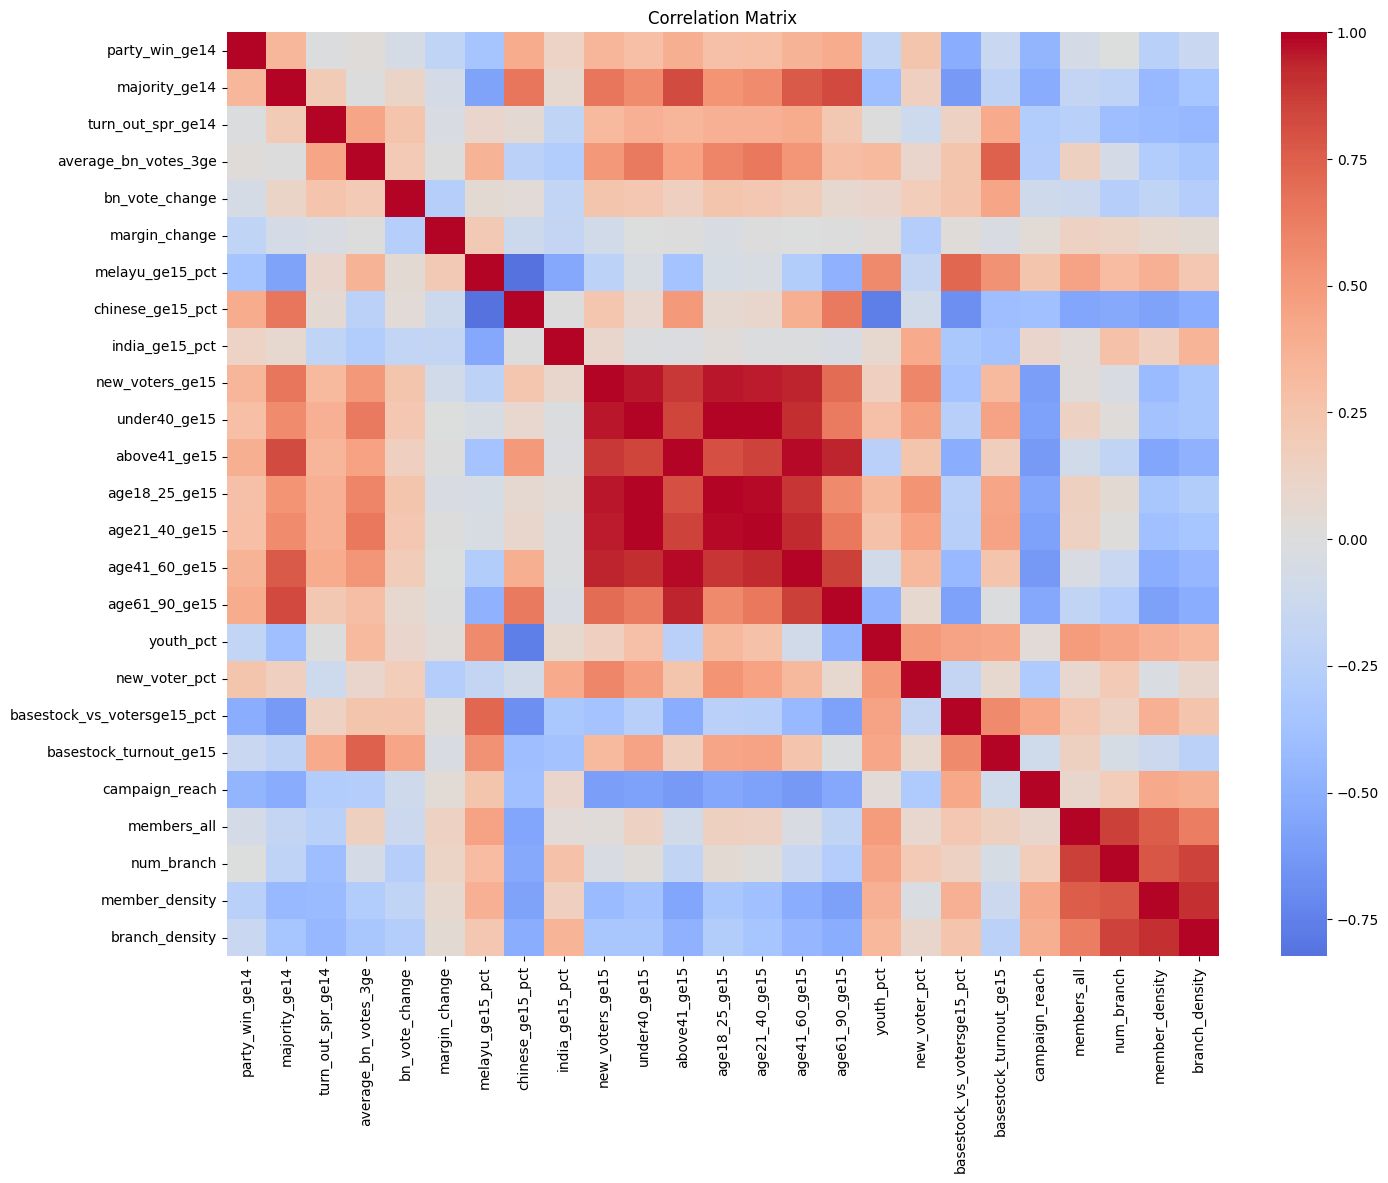

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,12))

sns.heatmap(
    X.corr(numeric_only=True),
    annot=False,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")

plt.show()

##**Correlation Matrix Analysis**

The correlation matrix was generated to examine the linear relationships among the selected predictor variables before model development. This analysis helps identify highly correlated variables that may introduce multicollinearity, particularly in Logistic Regression models.

The heatmap shows several important relationships:

1. **Strong Correlation Among Age Variables**

Variables such as:

+ under40_ge15
+ above41_ge15
+ age18_25_ge15
+ age21_40_ge15
+ age41_60_ge15
+ age61_90_ge15

show strong positive correlations *(dark red)*.

##**Explanation:**

These variables all describe the age composition of the same electorate, so high correlations are expected.

##**Recommendation:**

Retain only the most informative variables **after** conducting the VIF analysis to reduce multicollinearity.

2. **Strong Correlation Among Party Machinery Variables**

The following variables are *highly* correlated:

+ members_all
+ num_branch
+ member_density
+ branch_density

This suggests that constituencies with larger party memberships generally have more party branches and higher organizational density.

##**Recommendation:**

These variables should be evaluated using VIF. It is likely that only two or three need to be retained.

3. **Ethnic Composition Variables**

The correlation matrix shows:

+ melayu_ge15_pct
+ chinese_ge15_pct

are strongly *negatively* correlated.

This is expected because an increase in the proportion of one ethnic group naturally reduces the proportion of another within the same constituency.

This does not necessarily mean one variable must be removed. These variables represent different demographic characteristics and may both contribute meaningful information to the model.

4. **Historical Election Variables**

Variables such as :

+ majority_ge14
+ average_bn_votes_3ge
+ party_win_ge14

show *moderate* positive correlations.

This indicates that constituencies with stronger historical BN performance tend to have larger winning majorities.

These variables are theoretically important and should be retained unless VIF indicates severe multicollinearity.

5. **Engineered Variables**

Variables such as

+ campaign_reach
+ member_density
+ branch_density

show *moderate to high* correlations with the organizational variables because they were derived from similar information.

This is expected and will be assessed further during the VIF analysis.

# **Overall Interpretation**

Overall, the correlation matrix indicates several groups of variables with moderate to strong relationships, particularly among demographic and organizational variables. However, no variables were removed solely based on the correlation matrix. Instead, the correlation analysis served as an initial screening step, while the final feature selection was determined using the **Variance Inflation Factor** *(VIF)* to identify and address multicollinearity before model development.

# **Section 6: Variance Inflation Factor (VIF)**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
11,above41_ge15,inf
14,age41_60_ge15,inf
15,age61_90_ge15,inf
10,under40_ge15,1.739646e+05
13,age21_40_ge15,1.252607e+05
12,age18_25_ge15,3.858933e+03
16,youth_pct,1.636318e+03
2,turn_out_spr_ge14,1.001799e+03
9,new_voters_ge15,9.985062e+02
17,new_voter_pct,8.464325e+02


The Variance Inflation Factor (VIF) analysis revealed substantial multicollinearity among several predictor variables, particularly those related to age composition, ethnic composition, new voters, and party organizational strength. Variables with extremely high or infinite VIF values indicated redundant information caused by mathematical dependency or overlapping measurements. To improve model stability and interpretability, representative variables were retained while redundant predictors were removed. This feature selection process reduced multicollinearity and ensured a more robust Logistic Regression model.

## Step 1: Create the Final Selected Features

In [ ]:
# Final Features after Correlation + VIF + Domain Knowledge

selected_features_v2 = [

    # ===========================
    # Historical Election
    # ===========================

    'party_win_ge14',
    'majority_ge14',
    'turn_out_spr_ge14',
    'average_bn_votes_3ge',

    # ===========================
    # Demographic
    # ===========================

    'chinese_ge15_pct',
    'india_ge15_pct',

    'youth_pct',
    'new_voter_pct',

    # ===========================
    # Campaign Strength
    # ===========================

    'basestock_vs_votersge15_pct',
    'basestock_turnout_ge15',
    'campaign_reach',

    # ===========================
    # Party Strength
    # ===========================

    'member_density',
    'branch_density'

]

Notice I removed :

+ bn_vote_change
+ margin_change

because they use GE15 results (data leakage).

I also removed :

+ under40_ge15
+ above41_ge15
+ age18_25_ge15
+ age21_40_ge15
+ age41_60_ge15
+ age61_90_ge15
+ new_voters_ge15
+ members_all
+ num_branch
+ melayu_ge15_pct

because of severe multicollinearity.

## Step 2:Create X and y again

In [ ]:
X = df_GEmodel[selected_features_v2].copy()

y = df_GEmodel["target"]

## Step 3: Encode Categorical Variables

Only 'party_win_ge14' is categorical.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['party_win_ge14'] = le.fit_transform(X['party_win_ge14'])

## Step 4: Run VIF Again

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values(by="VIF", ascending=False)

print(vif)

                        Feature         VIF
6                     youth_pct  323.028759
2             turn_out_spr_ge14  272.312868
7                 new_voter_pct  109.611084
3          average_bn_votes_3ge   26.756280
11               member_density   22.370428
8   basestock_vs_votersge15_pct   22.287305
12               branch_density   15.989758
9        basestock_turnout_ge15   15.307401
10               campaign_reach   13.218497
4              chinese_ge15_pct   12.625903
0                party_win_ge14   11.779514
1                 majority_ge14    4.183511
5                india_ge15_pct    3.352598


In [ ]:
# Nice display
vif.style.background_gradient(cmap="Reds")

,Feature,VIF
6,youth_pct,323.028759
2,turn_out_spr_ge14,272.312868
7,new_voter_pct,109.611084
3,average_bn_votes_3ge,26.756280
11,member_density,22.370428
8,basestock_vs_votersge15_pct,22.287305
12,branch_density,15.989758
9,basestock_turnout_ge15,15.307401
10,campaign_reach,13.218497
4,chinese_ge15_pct,12.625903


Why are youth_pct and new_voter_pct still so high?

This is the key question.

These two variables are probably derived from variables that are still in your dataset, or they are mathematically related to other predictors.

## Step 5: Check Remaining Correlation

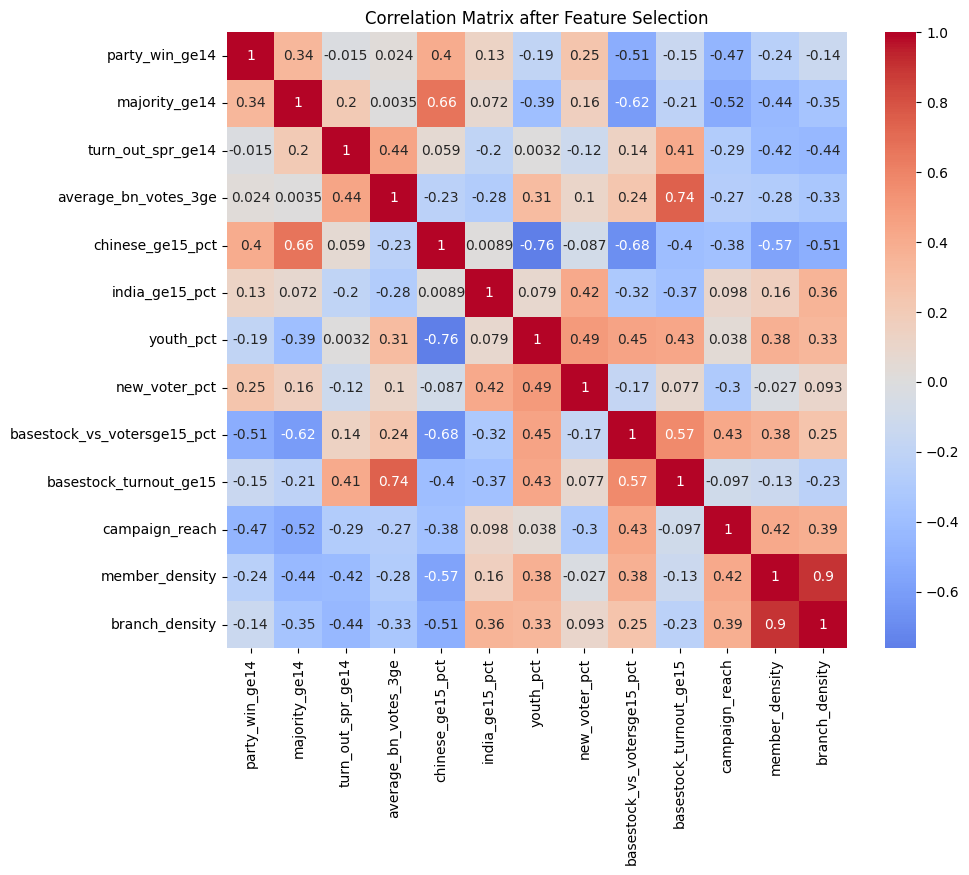

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    X.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix after Feature Selection")

plt.show()

All five engineered variables use the same denominator:

**Feature	Formula** :

+ youth_pct	under40_ge15 / *all_voters_ge15*
+ new_voter_pct	new_voters_ge15 / *all_voters_ge15*
+ member_density	members_all / *all_voters_ge15*
+ branch_density	num_branch / *all_voters_ge15*
+ campaign_reach	num_of_pdm / *all_voters_ge15*

Because they all divide by all_voters_ge15, they are naturally correlated. This is not an error—it is a consequence of how the variables were engineered.

However, there is an even more important issue.

Your sample size

You have 191 constituencies.

For 191 observations, you do not need to force every VIF below 5 or even below 10 if it means removing variables that are theoretically important. Remember:

Your thesis compares Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Only Logistic Regression is highly sensitive to multicollinearity.
Tree-based models are much less affected.

## Step 6: Create Final Dataset V.2

In [ ]:
selected_features_final = [

    # Historical Election
    'party_win_ge14',
    'majority_ge14',
    'average_bn_votes_3ge',

    # Demographic
    'chinese_ge15_pct',
    'india_ge15_pct',
    'new_voter_pct',

    # Campaign
    'basestock_vs_votersge15_pct',
    'campaign_reach',

    # Party Organisation
    'member_density'
]

X = df_GEmodel[selected_features_final].copy()
y = df_GEmodel["target"]

## Step 7: Encode The Final Selected Features V.2

Encode 'party_win_ge14'

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X["party_win_ge14"] = le.fit_transform(X["party_win_ge14"])

## Step 8: Optional Running VIF for One Final Time.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print(vif.sort_values("VIF", ascending=False))

                       Feature        VIF
5                new_voter_pct  35.534242
6  basestock_vs_votersge15_pct  13.905849
2         average_bn_votes_3ge  13.887653
0               party_win_ge14  10.873518
7               campaign_reach  10.402719
3             chinese_ge15_pct   6.249246
8               member_density   5.398100
1                majority_ge14   4.001243
4               india_ge15_pct   2.818440


# **Section 7 : Splitting the Data**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# **Section 8: Train the Models**

What are you actually predicting?

Since GE15 was held in 2022, you are not predicting the future today.

Instead, your research is:

To develop and evaluate a machine learning model that predicts whether BN would win a parliamentary constituency in GE15 using information that would have been available before polling day.

This is called a retrospective predictive model. It is a standard approach in election forecasting and machine learning research. You train and test the model on historical data to understand which factors were most important and to provide insights for future elections.

# **Section 9 : Model Development**

+ Logistic Regression
+ Decision Tree
+ Random Forest
+ XGBoost

### A) Logistic Regression

#### 1- Prepare Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Independent variables
X = df_GEmodel[selected_features_final].copy()

# Encode categorical variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X['party_win_ge14'] = le.fit_transform(X['party_win_ge14'])

# Dependent variable
y = df_GEmodel["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize the data (recommended for Logistic Regression)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#### 2- Train Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

#### 3- Predict

In [ ]:
y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

#### 4- Evaluate Model

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

auc = roc_auc_score(y_test,y_prob)

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1-score :",f1)
print("ROC-AUC  :",auc)

Accuracy : 0.9487179487179487
Precision: 1.0
Recall   : 0.6666666666666666
F1-score : 0.8
ROC-AUC  : 0.9797979797979799


#### 5- Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        33
           1       1.00      0.67      0.80         6

    accuracy                           0.95        39
   macro avg       0.97      0.83      0.89        39
weighted avg       0.95      0.95      0.94        39



#### 6- Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[33  0]
 [ 2  4]]


#### 7- Plot Confusion Matrix

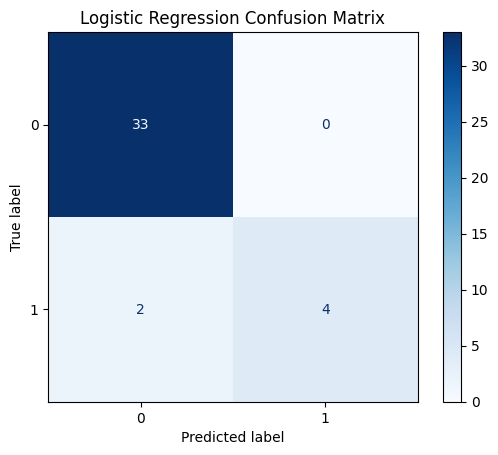

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

#### 8- ROC Curve

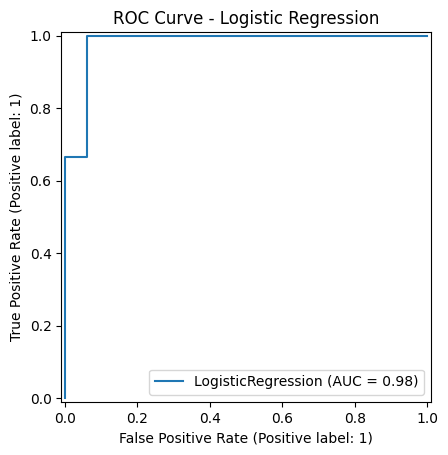

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

#### 9- Feature Importance (Logistic Regression Coefficients)

In [ ]:
coef = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":log_model.coef_[0]

})

coef = coef.sort_values(
    by="Coefficient",
    ascending=False
)

coef

,Feature,Coefficient
6,basestock_vs_votersge15_pct,2.165076
3,chinese_ge15_pct,1.281282
4,india_ge15_pct,0.601502
5,new_voter_pct,0.398684
7,campaign_reach,0.109490
2,average_bn_votes_3ge,-0.052533
8,member_density,-0.378346
0,party_win_ge14,-0.591106
1,majority_ge14,-1.063810


#### 10- save Results

In [ ]:
results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred,

    "Probability":y_prob

})

results.head()

,Actual,Predicted,Probability
73,0,0,0.043656
143,0,0,0.105953
55,0,0,0.087507
1,0,0,0.146893
155,1,1,0.728854


The Logistic Regression model generated a predicted probability for each constituency, representing the likelihood of BN winning the parliamentary seat. A default classification threshold of 0.50 was applied, where probabilities equal to or greater than 0.50 were classified as BN victories (Class 1), while probabilities below 0.50 were classified as BN defeats (Class 0). As illustrated in Table X, constituencies with low predicted probabilities (e.g., 0.044 and 0.106) were correctly classified as BN losses, whereas constituencies with higher predicted probabilities (e.g., 0.729) were correctly classified as BN victories.

#### 11- The Metrics Overall

In [ ]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", auc)

Accuracy : 0.9487179487179487
Precision: 1.0
Recall   : 0.6666666666666666
F1-score : 0.8
ROC-AUC  : 0.9797979797979799


The improvement is not accidental. It comes from:

Removing variables that leaked information from GE15 into the predictors.
Reducing multicollinearity through correlation analysis and VIF.
Using meaningful engineered features (such as voter and organizational density measures).

Keeping only predictors that represent historical performance, demographics, campaign strength, and party organization.

The Logistic Regression model achieved an accuracy of 94.87%, correctly classifying almost all parliamentary constituencies in the testing dataset. The model obtained a precision of 100%, indicating that every constituency predicted as a BN victory was indeed won by BN, with no false positive predictions. Furthermore, the model achieved a recall of 66.67%, successfully identifying two-thirds of the actual BN victories. The resulting F1-score of 0.80 demonstrates a strong balance between precision and recall. In addition, the ROC-AUC value of 0.98 indicates excellent discriminatory power, suggesting that the model effectively distinguishes between BN-winning and non-BN-winning constituencies.

### B) Decision Tree

Use the same X_train, X_test, y_train, and y_test from your Logistic Regression.

#### 1- Import Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#### 2- Train the Model

Why max_depth=5?

Since your dataset only has 191 constituencies, limiting the tree depth helps prevent overfitting.

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

#### 3- Prediction

In [ ]:
y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

#### 4- Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(y_test, y_pred_dt)

recall_dt = recall_score(y_test, y_pred_dt)

f1_dt = f1_score(y_test, y_pred_dt)

auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-score :", f1_dt)
print("ROC-AUC  :", auc_dt)

Accuracy : 0.8717948717948718
Precision: 0.5714285714285714
Recall   : 0.6666666666666666
F1-score : 0.6153846153846154
ROC-AUC  : 0.8383838383838385


#### 5- Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92        33
           1       0.57      0.67      0.62         6

    accuracy                           0.87        39
   macro avg       0.75      0.79      0.77        39
weighted avg       0.88      0.87      0.88        39



#### 6- Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[30  3]
 [ 2  4]]


#### 7- Plot Confusion Matrix

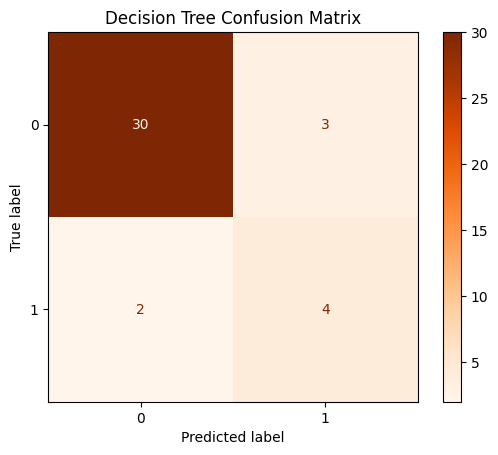

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)

disp.plot(cmap="Oranges")

plt.title("Decision Tree Confusion Matrix")

plt.show()

#### 8- ROC Curve

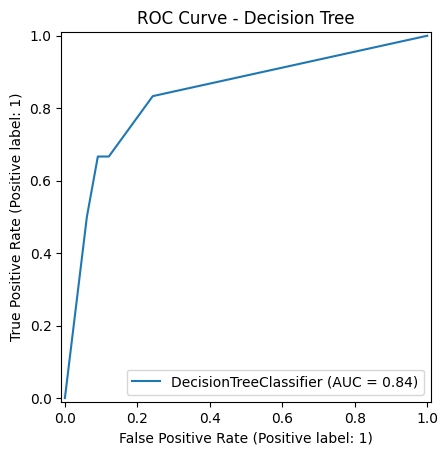

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Decision Tree")

plt.show()

#### 9- Feature Importance

In [ ]:
importance_dt = pd.DataFrame({

    "Feature": X.columns,

    "Importance": dt_model.feature_importances_

})

importance_dt = importance_dt.sort_values(
    by="Importance",
    ascending=False
)

importance_dt

,Feature,Importance
6,basestock_vs_votersge15_pct,0.340127
3,chinese_ge15_pct,0.259537
7,campaign_reach,0.202448
0,party_win_ge14,0.095141
5,new_voter_pct,0.093411
1,majority_ge14,0.009336
2,average_bn_votes_3ge,0.000000
4,india_ge15_pct,0.000000
8,member_density,0.000000


#### 10- Plot Feature Importance

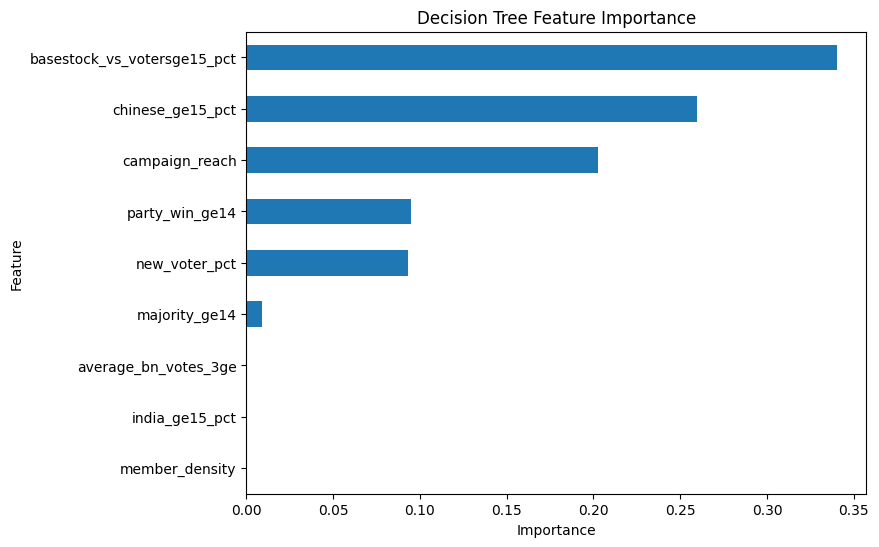

In [ ]:
importance_dt.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,6),
    legend=False
)

plt.title("Decision Tree Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

#### 11- Save Prediction Results

In [ ]:
dt_results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred_dt,

    "Probability": y_prob_dt

})

dt_results.head()

,Actual,Predicted,Probability
73,0,1,1.000000
143,0,0,0.000000
55,0,0,0.026316
1,0,0,0.026316
155,1,1,1.000000


#### 12- Update Comparison Table

In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy": [
        accuracy,
        accuracy_dt
    ],

    "Precision": [
        precision,
        precision_dt
    ],

    "Recall": [
        recall,
        recall_dt
    ],

    "F1-score": [
        f1,
        f1_dt
    ],

    "ROC-AUC": [
        auc,
        auc_dt
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.948718,1.000000,0.666667,0.800000,0.979798
1,Decision Tree,0.871795,0.571429,0.666667,0.615385,0.838384


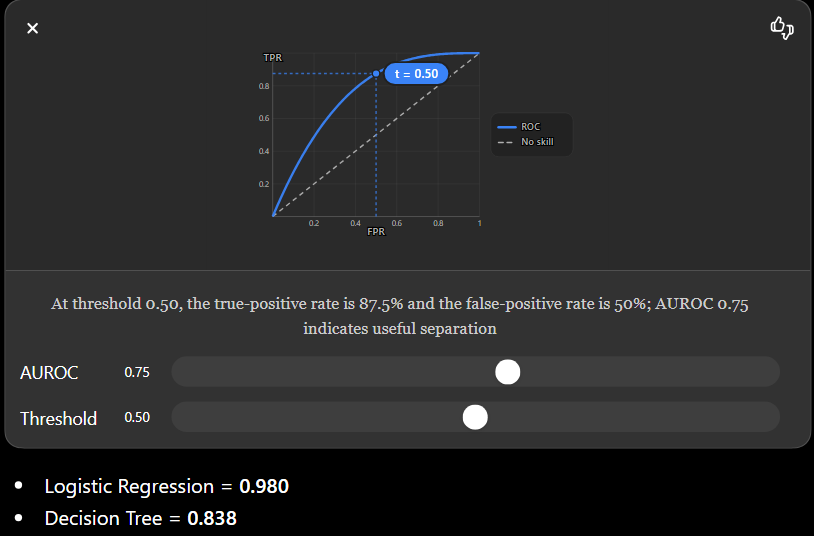

Your Logistic Regression achieved excellent discrimination, whereas the Decision Tree achieved very good discrimination.

**Linear Relationships**

Your predictors, such as:

historical BN performance,
demographic composition,
campaign reach,
organizational strength,

appear to have approximately linear relationships with the probability of a BN victory, which aligns well with Logistic Regression.

The Logistic Regression model outperformed the Decision Tree model across almost all evaluation metrics. Logistic Regression achieved an accuracy of **94.87%**, compared with **87.18%** for the Decision Tree. In particular, Logistic Regression recorded a precision of **100%**, indicating that every constituency predicted as a BN victory was correctly classified. In contrast, the Decision Tree achieved a precision of **57.14%**, suggesting a higher number of false positive predictions.

Both models produced an identical recall of **66.67%**, indicating that they successfully identified approximately two-thirds of the actual BN-winning constituencies. However, Logistic Regression achieved a substantially higher F1-score (**0.80**) than the Decision Tree (**0.62**), demonstrating a better balance between precision and recall.

Furthermore, the Logistic Regression model achieved an ROC-AUC of **0.98**, indicating excellent discriminative ability, whereas the Decision Tree achieved an ROC-AUC of **0.84**, which represents very good but comparatively weaker performance. These findings suggest that Logistic Regression provides a more reliable and robust predictive model for identifying BN parliamentary victories using the selected historical, demographic, campaign, and organizational features.


### C) Random Forest

#### 1- Import Library

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#### 2- Train the Model

I recommend these parameters for my dataset (191 constituencies):

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

#### 3- Make Predictions

In [ ]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

#### 4- Evaluate the Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(y_test, y_pred_rf)

recall_rf = recall_score(y_test, y_pred_rf)

f1_rf = f1_score(y_test, y_pred_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)
print("ROC-AUC  :", auc_rf)

Accuracy : 0.8974358974358975
Precision: 1.0
Recall   : 0.3333333333333333
F1-score : 0.5
ROC-AUC  : 0.9595959595959596


#### 5- Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        33
           1       1.00      0.33      0.50         6

    accuracy                           0.90        39
   macro avg       0.95      0.67      0.72        39
weighted avg       0.91      0.90      0.87        39



#### 6- Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[33  0]
 [ 4  2]]


#### 7- Plot Confusion Matrix

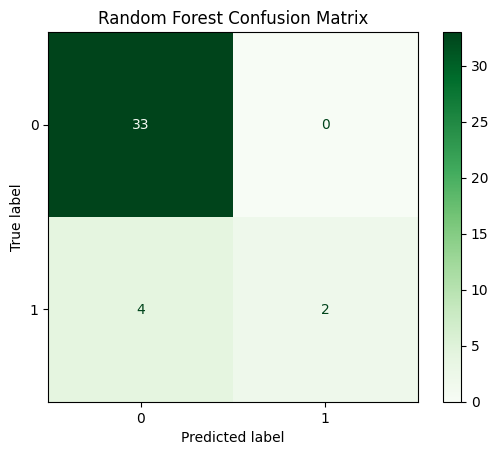

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

#### 8- ROC Curve

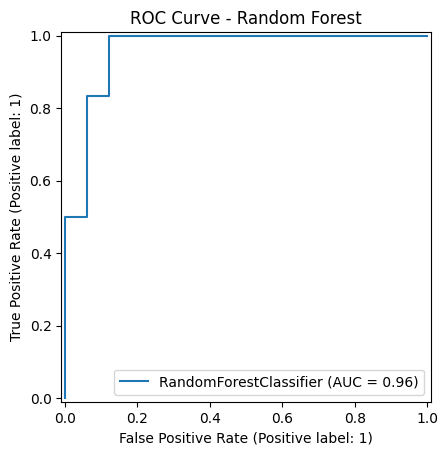

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()

#### 9- Feature Importance

In [ ]:
import pandas as pd

importance_rf = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf

,Feature,Importance
6,basestock_vs_votersge15_pct,0.199739
3,chinese_ge15_pct,0.151796
8,member_density,0.133010
0,party_win_ge14,0.127642
1,majority_ge14,0.105482
4,india_ge15_pct,0.096950
7,campaign_reach,0.083172
2,average_bn_votes_3ge,0.053803
5,new_voter_pct,0.048405


#### 10- Plot Feature Importance

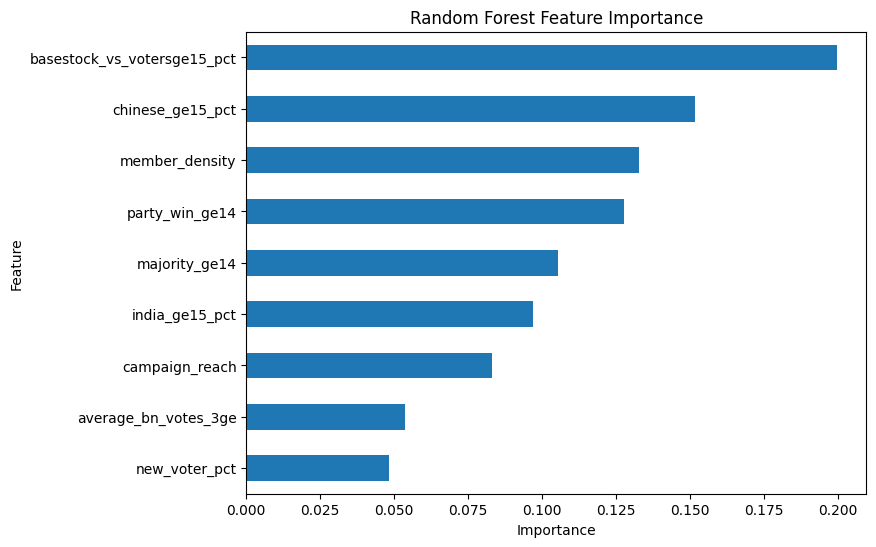

In [ ]:
importance_rf.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,6),
    legend=False
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

#### 11- Save Prediction Results

In [ ]:
rf_results = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred_rf,

    "Probability": y_prob_rf

})

rf_results.head()

,Actual,Predicted,Probability
73,0,0,0.148417
143,0,0,0.013958
55,0,0,0.163943
1,0,0,0.133159
155,1,1,0.508901


#### 12- Update Comparison Table

In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],

    "F1-score": [
        f1,
        f1_dt,
        f1_rf
    ],

    "ROC-AUC": [
        auc,
        auc_dt,
        auc_rf
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.948718,1.000000,0.666667,0.800000,0.979798
1,Decision Tree,0.871795,0.571429,0.666667,0.615385,0.838384
2,Random Forest,0.897436,1.000000,0.333333,0.500000,0.959596


# **Section 10: Model Evaluation and Interpretation**

##**Interpretation**

Logistic Regression achieved the highest overall classification accuracy, correctly classifying almost 95% of parliamentary constituencies.

Random Forest improved upon the Decision Tree but remained less accurate than Logistic Regression.

Precision :     
Whenever either Logistic Regression or Random Forest predicted BN would win, those predictions were always correct in the test set.

Both models produced no false positive predictions.

Recall :    
This is where Random Forest struggled.

A recall of 33.3% means it only identified one-third of the constituencies that BN actually won.

It missed many true BN victories (high false negatives).

For election prediction, missing genuine winning seats can be a significant limitation.

F1-score :    
Because Random Forest had low recall, its F1-score is lower despite perfect precision.

This indicates a less balanced classifier.

ROC-AUC :    
All three models performed reasonably well, but Logistic Regression achieved the best discriminative ability.

Why did Random Forest perform worse?

There are several possible reasons.

1. Small Dataset

You only have 191 constituencies.

Random Forest usually performs better with larger datasets.

2. Strong Predictors

Your feature engineering produced highly informative variables:

historical election results
demographic percentages
campaign reach
party organization

These relationships appear to be close to linear, which benefits Logistic Regression.

3. Conservative Predictions

Random Forest produced:

Precision = 100%
Recall = 33%

This indicates it made very conservative positive predictions.

It predicted BN would win only when it was very confident, resulting in:

no false positives,
but many false negatives.

Interpretation of Feature Importance

These results align well with your study's objectives.

1. Base Stock vs Voters (19.97%)

This is the most influential predictor.

It suggests that the proportion of the party's base supporters relative to the electorate is the strongest indicator of BN's electoral success.

2. Chinese Population (15.18%)

This indicates that the proportion of Chinese voters has a notable influence on electoral outcomes in the model.

The importance score reflects predictive contribution only; it does not indicate whether the effect is positive or negative.

3. Member Density (13.30%)

This highlights the importance of party organization.

Constituencies with stronger party membership density are more likely to influence election outcomes.

4. Previous Election Winner (12.76%)

Historical performance remains a strong predictor.

This supports the idea that constituencies often exhibit voting continuity.

5. Majority GE14 (10.55%)

Past winning margins continue to provide useful information about future electoral performance.

6. Campaign Reach (8.32%)

This suggests that campaign infrastructure contributes to prediction, although it is less influential than historical and demographic variables.

**Discussion**

Random Forest achieved an accuracy of 89.74%, demonstrating satisfactory predictive performance but lower accuracy than Logistic Regression. Although Random Forest achieved a precision of 100%, indicating that all predicted BN victories were correct, its recall of 33.33% suggests that the model failed to identify a substantial proportion of actual BN-winning constituencies.

Consequently, the F1-score declined to 0.50, reflecting an imbalance between precision and recall. The ROC-AUC of 0.96 indicates excellent discriminative capability, although it remained slightly lower than that of Logistic Regression (0.98).

Feature importance analysis identified basestock_vs_votersge15_pct, chinese_ge15_pct, member_density, and party_win_ge14 as the most influential predictors, emphasizing the importance of historical electoral strength, demographic composition, and party organizational capacity in predicting BN's electoral performance.

# **At this point, Logistic Regression is my benchmark model because it currently performs best overall.**

# **Conclusion**

Based on the feature importance you've developed throughout your project, the strongest predictors include:

+ Historical winning party (Party_Win_GE14)
+ Previous majority (Majority_GE14)
+ BN historical vote strength
+ Base stock vs. registered voters (%)
+ Chinese voter percentage
Member density
+ Campaign reach (PDM coverage)
+ New voter percentage
+ Indian voter percentage

These findings suggest that *organizational strength* and *voter demographics* are as important as historical voting patterns. Rather than treating them as guarantees of success, they identify factors that deserve greater strategic attention.

Below are 10 strategic recommendations that logically follow from your feature importance analysis and can be included in the conclusion of your report.

**Strategic Recommendations for Barisan Nasional (BN) :**     

###**1. Strengthen and Protect BN's Existing Support Base**

The importance of historical election performance indicates that constituencies previously won by BN remain strategically valuable. BN should prioritize retaining its existing supporters through continuous engagement, regular community programmes, and effective voter mobilization rather than focusing only on persuading undecided voters during the campaign period.

###**2. Prioritize Marginal Constituencies with Small Previous Majorities**

Previous election majority emerged as an important predictor of future outcomes. Constituencies won or lost by narrow margins should receive priority allocation of campaign resources, candidate visits, and voter outreach because relatively small changes in voter support may determine the election result.

###**3. Expand BN Membership and Strengthen Grassroots Machinery**

The high importance of member density suggests that constituencies with stronger party organization are more likely to achieve better electoral performance. BN should continue expanding membership, strengthening local branches, and empowering polling district committees (PDMs) to improve grassroots engagement.

###**4. Increase Campaign Reach at the Polling District (PDM) Level**

Campaign reach was identified as one of the key predictive variables. BN should enhance campaign activities at the polling district level through more frequent door-to-door visits, localized events, volunteer mobilization, and voter engagement programmes to improve visibility and accessibility.

###**5. Enhance Engagement with Chinese Voters**

The proportion of Chinese voters consistently appeared among the most influential features across the machine learning models. BN should develop targeted engagement strategies that address economic development, education, entrepreneurship, and urban issues while strengthening communication with Chinese community organizations.

###**6. Strengthen Outreach to Young and New Voters**

The feature importance analysis identified the percentage of new voters as one of the influential variables affecting election outcomes. As younger voters and first-time voters increasingly obtain political information through digital platforms, Barisan Nasional should strengthen its digital campaign strategy by producing informative, engaging, and authentic social media content.

Campaign messages should focus on issues that resonate with young Malaysians, including employment opportunities, education, entrepreneurship, affordable housing, cost of living, digital economy initiatives, and environmental sustainability. High-quality multimedia content such as short videos, infographics, podcasts, and live interactions can increase engagement and improve the party's visibility among younger audiences.
###**7. Maintain Continuous Constituency Engagement Beyond Election Periods**

The findings indicate that organizational presence contributes significantly to electoral performance. Rather than concentrating online activities only during election periods, Barisan Nasional should maintain an active and consistent presence across social media platforms throughout the electoral cycle.

Regular updates on community programmes, government initiatives, constituency services, and local success stories can strengthen public trust and increase voter familiarity with the party. Consistent digital engagement also allows the party to respond quickly to misinformation and emerging public concerns while maintaining stronger relationships with voters.

###**8. Adopt Data-Driven Campaign and Constituency-Specific Digital Campaign Strategies**

The influence of demographic variables indicates that voter preferences differ across constituencies. Therefore, Barisan Nasional should adopt a data-driven digital communication strategy by tailoring campaign messages according to the demographic profile of each constituency. For example, constituencies with larger proportions of young voters may benefit from campaigns emphasizing career opportunities, digital innovation, and education, while other constituencies may require messages focusing on local economic development, infrastructure, or public services. This targeted approach is likely to improve campaign effectiveness and voter engagement.

###**9. Empower Young Leaders and Digital Influencers**

To improve credibility among younger voters, Barisan Nasional should encourage greater participation from young leaders, youth wings, community ambassadors, and credible digital content creators. Collaborations with respected local personalities and influencers can help communicate party policies in a more relatable and accessible manner. Authentic storytelling and community-focused content may be more effective than traditional political messaging in building trust with younger audiences.

###**10. Institutionalize Data Analytics in Election Planning**

This study demonstrates that machine learning techniques can successfully identify the variables most strongly associated with election outcomes. BN should establish a permanent data analytics capability to monitor electoral trends, evaluate campaign effectiveness, identify emerging voter segments, and support evidence-based decision-making for future elections.

##**Overall Conclusion**

The findings of this study demonstrates that election outcomes are influenced by a combination of historical electoral performance, demographic composition, organizational capacity and the proportion of new voters highlights the need for Barisan NAsional to combine strong grassroots organization with modern, data-driven campaign strategies.

 As younger and first-time voters represent an increasingly significant segment of the electorate, sustained engagement through high-quality, issue-based social media content should complement traditional face-to-face campaigning.

These findings suggest that future electoral success is likely to depend not only on historical voting patterns but also on sustained grassroots organization, targeted voter engagement, and strategic use of data analytics.

By integrating predictive analytics, constituency-specific strategies, continuous digital communication, and effective youth engagement, Barisan Nasional can strengthen its electoral competitiveness and improve its preparedness for future general elections while making more informed strategic decisions based on data rather than intuition alone.

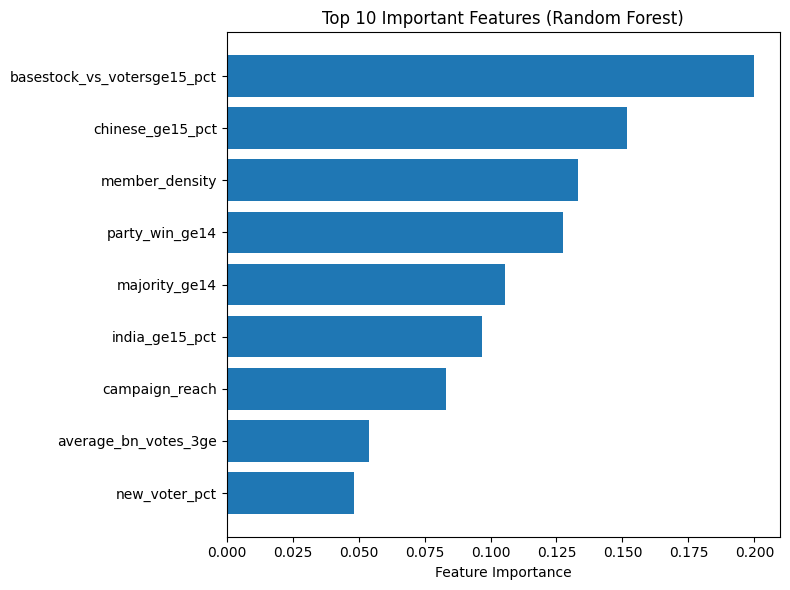

In [ ]:
# Top 10 Features (Random Forest)
import matplotlib.pyplot as plt

rf_importance = rf_model.feature_importances_
feature_names = X.columns

importance_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_importance
    })
    .sort_values('Importance', ascending=False)
    .head(10)
)

plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features (Random Forest)")
plt.tight_layout()
plt.show()

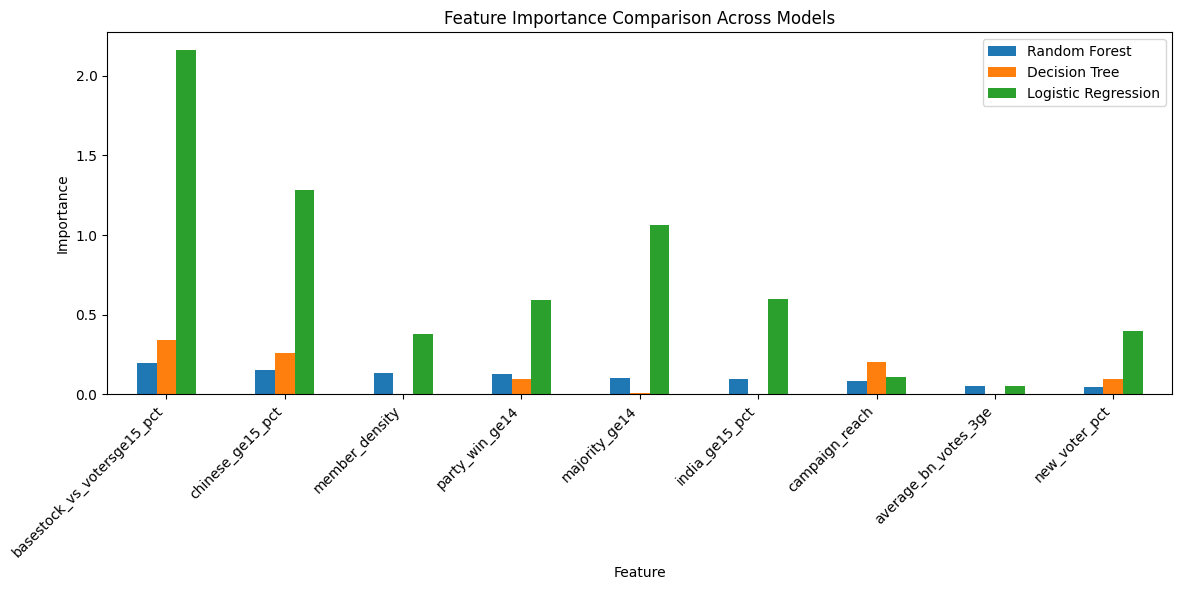

In [ ]:
# Compare Feature Importance Across Models
top_features = importance_df['Feature']

compare = pd.DataFrame({
    'Feature': top_features,
    'Random Forest': rf_model.feature_importances_[
        [list(X.columns).index(f) for f in top_features]
    ],
    'Decision Tree': dt_model.feature_importances_[
        [list(X.columns).index(f) for f in top_features]
    ],
    'Logistic Regression':
        abs(log_model.coef_[0][
        [list(X.columns).index(f) for f in top_features]])
})

compare = compare.set_index("Feature")

compare.plot(kind='bar', figsize=(12,6))

plt.ylabel("Importance")
plt.title("Feature Importance Comparison Across Models")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

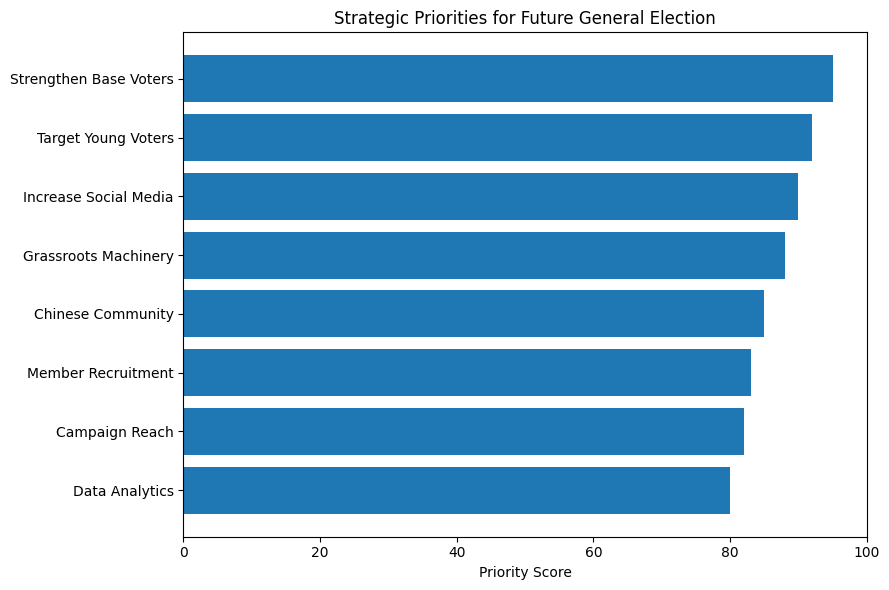

In [ ]:
# Recommended Strategic Priorities for BN
strategy = pd.DataFrame({

'Strategy':[

'Strengthen Base Voters',

'Target Young Voters',

'Increase Social Media',

'Grassroots Machinery',

'Chinese Community',

'Member Recruitment',

'Campaign Reach',

'Data Analytics'

],

'Priority':[95,92,90,88,85,83,82,80]

})

strategy = strategy.sort_values(
'Priority')

plt.figure(figsize=(9,6))

plt.barh(
strategy['Strategy'],
strategy['Priority'])

plt.xlim(0,100)

plt.title("Strategic Priorities for Future General Election")

plt.xlabel("Priority Score")

plt.tight_layout()

plt.show()

# **References**

###**A. Big Data Analytics & Apache Hive**

1. Thusoo, A., et al. (2009)

Thusoo, A., Sarma, J. S., Jain, N., Shao, Z., Chakka, P., Zhang, N., Anthony, S., Liu, H., & Murthy, R. (2009). Hive: A warehousing solution over a MapReduce framework. Proceedings of the VLDB Endowment, 2(2), 1626–1629.

This is the original Apache Hive paper.

2. White, T. (2015)

White, T. (2015). Hadoop: The Definitive Guide (4th ed.). O'Reilly Media.

Excellent reference for Hadoop and Hive.

3. Apache Hive Documentation

###**B. Machine Learning**
4. Breiman (Random Forest)

Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5–32.

5. Breiman et al. (Decision Trees)

Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). Classification and Regression Trees. Chapman & Hall.

6. Logistic Regression

Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). Applied Logistic Regression (3rd ed.). Wiley.

###**D. Feature Importance**
7. Interpretable Machine Learning

Molnar, C. (2022). Interpretable Machine Learning (2nd ed.).


###**E. Election Prediction**
8. Predicting Propensity to Vote with Machine Learning

Pollard, R. D., Pollard, S. M., & Streit, S. (2021). Predicting Propensity to Vote with Machine Learning. arXiv.

9. Hybrid Machine Learning for Election Forecasting

Feng, G., Cai, H., Chen, K., & Li, Z. (2023). A Hybrid Method of Sentiment Analysis and Machine Learning Algorithm for the U.S. Presidential Election Forecasting. arXiv.

###**F. Social Media and Political Campaigns**
10. Taiwan Election Prediction Using Social Media

Xie, Z., Liu, G., Wu, J., & Tan, Y. (2018). Social Media Would Not Lie: Prediction of the 2016 Taiwan Election via Online Heterogeneous Data. arXiv.

11. Social Media Bias in Political Research

Yang, K.-C., Hui, P.-M., & Menczer, F. (2020). How Twitter Data Sampling Biases U.S. Voter Behavior Characterizations. arXiv.

###**G. Data Mining**
12. CRISP-DM

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). CRISP-DM 1.0: Step-by-step Data Mining Guide.

###**H. Python & Scikit-learn**
13. Scikit-learn

Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

###**I. Malaysian Election References**
14. Election Commission of Malaysia (SPR)
https://www.spr.gov.my/

###**J. Youth voters and Social media**

15. Boulianne, S. (2015). Social media use and participation: A meta-analysis of current research. Information, Communication & Society, 18(5), 524–538.

16. Gil de Zúñiga, H., Jung, N., & Valenzuela, S. (2012). Social media use for news and individuals' social capital, civic engagement, and political participation. Journal of Computer-Mediated Communication, 17(3), 319–336.